# 22AIE437 Medical Image Processing - Project Review
# Automated Retinal Blood Vessel Segmentation Using CAR-UNet on the FIVES Benchmark

**Authors / Project Group**: Medical Image Processing Team
**Upgrade Paper**: Guo et al. (IEEE ICASSP 2021 / arXiv:2004.03702) *"Channel Attention Residual U-Net for Retinal Vessel Segmentation"*
**Dataset Paper**: Jin et al. (Scientific Data, 2022) *"FIVES: A Fundus Image Dataset for AI-based Vessel Segmentation"*
**Baseline Paper**: Ronneberger et al. (MICCAI 2015) *"U-Net: Convolutional Networks for Biomedical Image Segmentation"*

---

## 🌟 Executive Summary

In **Review 1**, a baseline retinal vessel segmentation pipeline was implemented using the classical **Ronneberger U-Net** on the **DRIVE dataset** (40 images). It was limited by the very small dataset and has no attention mechanism.

In this version, we made a two-fold upgrade:
1. **Dataset Upgrade (DRIVE $\to$ FIVES)**: 800 high-resolution FIVES fundus images (**20x more data**) covering four groups: Normal, Age-Related Macular Degeneration (AMD), Diabetic Retinopathy (DR), and Glaucoma.
2. **Architecture Upgrade (Plain U-Net $\to$ CAR-UNet)**:
   - **MECA (Modified Efficient Channel Attention)**: 1D convolution across channels with adaptive kernel size $k = \psi(C)$.
   - **CADRB (Channel Attention Double Residual Blocks)**: Residual blocks with embedded channel attention.
   - **Bridge Attention**: MECA channel recalibration on skip connections before concatenation with decoder features.
3. **Fair evaluation protocol**: both models trained by the same script with identical settings (30 epochs, 6 fresh patches per image every epoch, elastic augmentation, cosine LR), **3 seeds each**, disease-stratified train/val split, and evaluation on **all 200 test images** (50 per disease) with Overlap-Tile inference.

**Result:** CAR-UNet Dice **0.8382 ± 0.0031** vs U-Net **0.8344 ± 0.0034** — a small but consistent improvement (better on 154/200 test images, p = 2.2×10⁻¹⁴), largest on Glaucoma and Normal images.


---
## 1. Setup & GPU Environment Verification
Verify CUDA acceleration on the NVIDIA RTX 4050 GPU and import all scientific libraries.

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
dll_paths = [
    r'D:\apps\Lib\site-packages\torch\lib',
    r'D:\apps\Library\bin',
    r'D:\apps\bin',
    r'D:\apps',
]
for p in dll_paths:
    if os.path.exists(p):
        os.environ['PATH'] = p + ';' + os.environ.get('PATH', '')
        if hasattr(os, 'add_dll_directory'):
            try:
                os.add_dll_directory(p)
            except Exception:
                pass
import sys
import math
import glob
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from scipy.ndimage import gaussian_filter, map_coordinates
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using Compute Device: {device}')
if torch.cuda.is_available():
    print(f'GPU Device Name:     {torch.cuda.get_device_name(0)}')
    print(f'CUDA Capability:     {torch.cuda.get_device_capability(0)}')
    print(f'Available Memory:    {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB')


Using Compute Device: cuda
GPU Device Name:     NVIDIA GeForce RTX 4050 Laptop GPU
CUDA Capability:     (8, 9)
Available Memory:    6.00 GB


---
## 2. Classical Medical Preprocessing Pipeline

Retinal fundus images suffer from uneven illumination and poor capillary contrast. Our optical preprocessing steps include:
1. **Green Channel Extraction**: Hemoglobin exhibits peak optical absorption at $540-575\text{ nm}$, yielding maximum vessel contrast.
2. **CLAHE (Contrast Limited Adaptive Histogram Equalization)**: `clip_limit=2.0`, `grid=(8,8)` boosts local microvascular contrast without amplifying noise.
3. **Bilateral Filtering**: Edge-preserving noise reduction (`d=5`, `sigma=75`) removes sensor speckle noise while preserving crisp vessel margins.
4. **Min-Max Normalization**: Scales pixel intensities to $[0.0, 1.0]$.
5. **Field of View (FOV) Masking**: Automatically detects the circular retinal boundary to mask background noise.

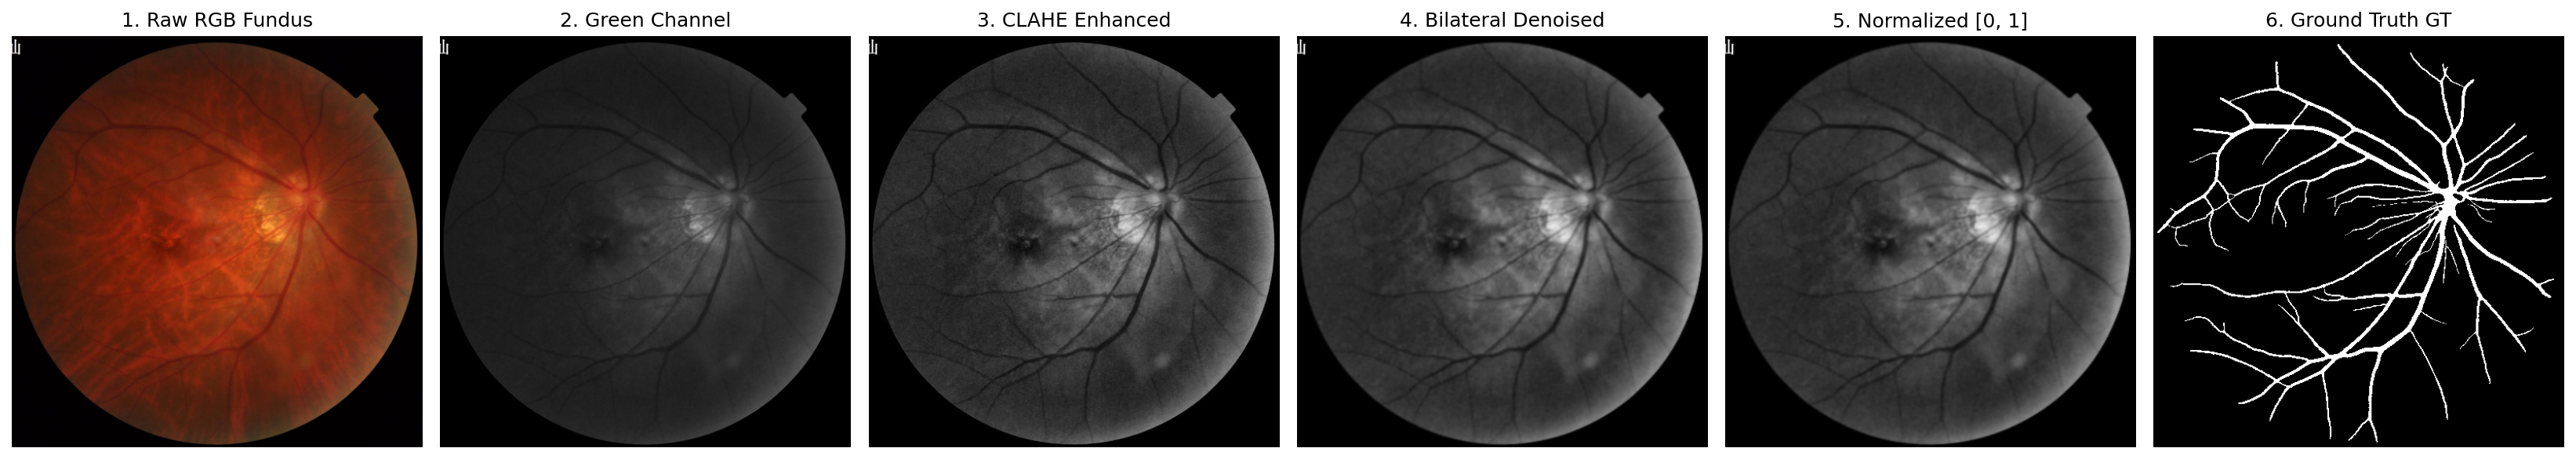

In [2]:
def extract_green_channel(image: np.ndarray) -> np.ndarray:
    if len(image.shape) == 3 and image.shape[2] == 3:
        return image[:, :, 1]
    return image

def apply_clahe(image: np.ndarray, clip_limit: float = 2.0, tile_grid_size: tuple = (8, 8)) -> np.ndarray:
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return clahe.apply(image)

def apply_noise_reduction(image: np.ndarray, method: str = 'bilateral') -> np.ndarray:
    if method == 'bilateral':
        return cv2.bilateralFilter(image, d=5, sigmaColor=75, sigmaSpace=75)
    elif method == 'median':
        return cv2.medianBlur(image, ksize=3)
    return image

def normalize_image(image: np.ndarray) -> np.ndarray:
    return image.astype(np.float32) / 255.0

def preprocess_image(image: np.ndarray, clip_limit: float = 2.0, tile_grid_size: tuple = (8, 8)) -> np.ndarray:
    green = extract_green_channel(image)
    clahe = apply_clahe(green, clip_limit=clip_limit, tile_grid_size=tile_grid_size)
    denoised = apply_noise_reduction(clahe, method='bilateral')
    return normalize_image(denoised)

def generate_fov_mask(image: np.ndarray, threshold: int = 10) -> np.ndarray:
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        gray = image
    _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    return (mask > 128).astype(np.float32)

# Visual Preprocessing Panel Demonstration
img_sample_paths = sorted(glob.glob('data/FIVES_resized/train/images/*.png'))
mask_sample_paths = sorted(glob.glob('data/FIVES_resized/train/masks/*.png'))

sample_raw_bgr = cv2.imread(img_sample_paths[0])
sample_raw_rgb = cv2.cvtColor(sample_raw_bgr, cv2.COLOR_BGR2RGB)
sample_green = extract_green_channel(sample_raw_rgb)
sample_clahe = apply_clahe(sample_green, clip_limit=2.0, tile_grid_size=(8, 8))
sample_denoised = apply_noise_reduction(sample_clahe, method='bilateral')
sample_prep = preprocess_image(sample_raw_rgb)
sample_gt = np.array(Image.open(mask_sample_paths[0]))

fig, axes = plt.subplots(1, 6, figsize=(22, 4))
axes[0].imshow(sample_raw_rgb); axes[0].set_title('1. Raw RGB Fundus'); axes[0].axis('off')
axes[1].imshow(sample_green, cmap='gray'); axes[1].set_title('2. Green Channel'); axes[1].axis('off')
axes[2].imshow(sample_clahe, cmap='gray'); axes[2].set_title('3. CLAHE Enhanced'); axes[2].axis('off')
axes[3].imshow(sample_denoised, cmap='gray'); axes[3].set_title('4. Bilateral Denoised'); axes[3].axis('off')
axes[4].imshow(sample_prep, cmap='gray'); axes[4].set_title('5. Normalized [0, 1]'); axes[4].axis('off')
axes[5].imshow(sample_gt, cmap='gray'); axes[5].set_title('6. Ground Truth GT'); axes[5].axis('off')
plt.tight_layout()
plt.show()


---
## 3. Patch Extraction, Ronneberger Elastic Deformation & Dataset Loader

- **Valid Convolution Geometry**: To eliminate zero-padding edge distortions, input patches of size $284 	imes 284$ are mapped to center output masks of size $100 	imes 100$ (92-pixel margin on all sides).
- **Elastic Deformations (Ronneberger et al. 2015)**: Smooth displacement vectors generated via Gaussian filtering simulate natural retinal physiological elasticity.
- **Fresh patches every epoch**: 6 new random FOV-centred patches are drawn from each training image at the start of every epoch (2,880 patches/epoch).
- **Disease-stratified split (fixed seed)**: 480 training images (120 per disease) and 120 validation images (30 AMD, 30 DR, 30 Glaucoma, 30 Normal), split at image level so no patch of a validation image is ever seen in training. All **200** test images (50 per disease) are used for the final evaluation.


In [3]:
def apply_elastic_transform(image: np.ndarray, mask: np.ndarray, alpha: float = 25.0, sigma: float = 4.0, random_state=None) -> tuple:
    if random_state is None:
        random_state = np.random.RandomState(None)
    img_shape = image.shape
    mask_shape = mask.shape
    dx = gaussian_filter((random_state.rand(*img_shape) * 2 - 1), sigma, mode='constant', cval=0) * alpha
    dy = gaussian_filter((random_state.rand(*img_shape) * 2 - 1), sigma, mode='constant', cval=0) * alpha
    y_img, x_img = np.meshgrid(np.arange(img_shape[0]), np.arange(img_shape[1]), indexing='ij')
    indices_img = np.reshape(y_img + dy, (-1, 1)), np.reshape(x_img + dx, (-1, 1))
    distorted_image = map_coordinates(image, indices_img, order=1, mode='reflect').reshape(img_shape)
    if img_shape == mask_shape:
        indices_mask = indices_img
    else:
        my = (img_shape[0] - mask_shape[0]) // 2
        mx = (img_shape[1] - mask_shape[1]) // 2
        y_mask, x_mask = np.meshgrid(np.arange(mask_shape[0]), np.arange(mask_shape[1]), indexing='ij')
        dx_mask = dx[my : my + mask_shape[0], mx : mx + mask_shape[1]]
        dy_mask = dy[my : my + mask_shape[0], mx : mx + mask_shape[1]]
        indices_mask = np.reshape(y_mask + dy_mask, (-1, 1)), np.reshape(x_mask + dx_mask, (-1, 1))
    distorted_mask = map_coordinates(mask, indices_mask, order=0, mode='reflect').reshape(mask_shape)
    return distorted_image, distorted_mask

DISEASE_NAMES = {'A': 'AMD', 'D': 'DR', 'G': 'Glaucoma', 'N': 'Normal'}

def get_disease_code(path: str) -> str:
    # FIVES filenames end in the disease code: '12_A.png' -> 'A'
    return os.path.splitext(os.path.basename(path))[0].split('_')[-1][0].upper()

def load_fives_image_pairs(data_dir: str, mode: str = 'train', val_ratio: float = 0.2, split_seed: int = 42):
    # Image-level, disease-stratified split: 480 train / 120 val (30 per disease), fixed seed.
    sub = 'test' if mode == 'test' else 'train'
    img_paths = sorted(glob.glob(os.path.join(data_dir, sub, 'images', '*.png')))
    mask_paths = sorted(glob.glob(os.path.join(data_dir, sub, 'masks', '*.png')))
    pairs = list(zip(img_paths, mask_paths))
    if mode == 'test':
        return pairs
    rng = np.random.RandomState(split_seed)
    train_pairs, val_pairs = [], []
    for code in sorted(set(get_disease_code(i) for i, _ in pairs)):
        group = [pr for pr in pairs if get_disease_code(pr[0]) == code]
        order = rng.permutation(len(group))
        n_val = int(round(len(group) * val_ratio))
        val_pairs += [group[k] for k in order[:n_val]]
        train_pairs += [group[k] for k in order[n_val:]]
    return sorted(train_pairs) if mode == 'train' else sorted(val_pairs)

print('Data loader and elastic augmentation routines defined successfully.')


Data loader and elastic augmentation routines defined successfully.


---
## 4. Combined BCE + Dice Loss & Clinical FOV Evaluation Metrics

### Loss Formulation
$$\mathcal{L}_{\text{total}} = 0.5 \cdot \mathcal{L}_{\text{BCE}} + 0.5 \cdot \mathcal{L}_{\text{Dice}}$$
Handles the extreme 1:12 class imbalance (vessels occupy $\approx 7.5\%$ of pixels).

### True Field of View (FOV) Evaluation
Medical metrics are computed **strictly inside the retinal circle** (background excluded) to prevent artificial metric inflation.

In [4]:
class DiceLoss(nn.Module):
    def __init__(self, smooth: float = 1.0):
        super().__init__()
        self.smooth = smooth
    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        pred_flat = pred.view(-1)
        target_flat = target.view(-1)
        intersection = (pred_flat * target_flat).sum()
        dice_score = (2.0 * intersection + self.smooth) / (pred_flat.sum() + target_flat.sum() + self.smooth)
        return 1.0 - dice_score

class CombinedBCEDiceLoss(nn.Module):
    def __init__(self, bce_weight: float = 0.5, dice_weight: float = 0.5, smooth: float = 1.0):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.bce = nn.BCELoss()
        self.dice = DiceLoss(smooth=smooth)
    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        return self.bce_weight * self.bce(pred, target) + self.dice_weight * self.dice(pred, target)

def compute_fov_metrics(pred_prob: np.ndarray, ground_truth: np.ndarray, fov_mask: np.ndarray, threshold: float = 0.5):
    fov_indices = np.where(fov_mask > 0.5)
    y_true = ground_truth[fov_indices].flatten().astype(int)
    y_prob = pred_prob[fov_indices].flatten()
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-8)
    sensitivity = tp / (tp + fn + 1e-8)
    specificity = tn / (tn + fp + 1e-8)
    precision = tp / (tp + fp + 1e-8)
    f1_dice = 2 * tp / (2 * tp + fp + fn + 1e-8)
    iou = tp / (tp + fp + fn + 1e-8)
    try:
        auc_roc = roc_auc_score(y_true, y_prob)
    except Exception:
        auc_roc = 0.0
    try:
        prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_prob)
        auc_pr = auc(rec_curve, prec_curve)
    except Exception:
        auc_pr = 0.0
    return {
        'Accuracy': float(accuracy),
        'Sensitivity': float(sensitivity),
        'Specificity': float(specificity),
        'Precision': float(precision),
        'F1_Dice': float(f1_dice),
        'IoU': float(iou),
        'AUC_ROC': float(auc_roc),
        'AUC_PR': float(auc_pr)
    }

print('Combined Loss and FOV metrics engine defined.')


Combined Loss and FOV metrics engine defined.


---
## 5. Model Architecture Definitions: Baseline U-Net vs. Upgraded CAR-UNet

### A. Modified Efficient Channel Attention (MECA)
Computes channel weights without dimensionality reduction via an adaptive 1D convolution:
$$k = \psi(C) = \left| \frac{\log_2(C) + b}{\gamma} \right|_{\text{odd}}$$

### B. Channel Attention Double Residual Block (CADRB)
Replaces standard convolutions with double residual mappings plus channel attention:
$$\mathbf{Y} = \text{ReLU}\left(\text{MECA}(\text{Conv}_{3\times 3}(\text{Conv}_{3\times 3}(\mathbf{X}))) + \text{Crop}(\text{Shortcut}(\mathbf{X}))\right)$$

In [5]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=0, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=0, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels: int = 1, out_channels: int = 1, base_filters: int = 64):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, base_filters)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.enc2 = DoubleConv(base_filters, base_filters * 2)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.enc3 = DoubleConv(base_filters * 2, base_filters * 4)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.enc4 = DoubleConv(base_filters * 4, base_filters * 8)
        self.pool4 = nn.MaxPool2d(2, 2)
        self.bottleneck = DoubleConv(base_filters * 8, base_filters * 16)
        self.dropout = nn.Dropout(0.5)
        self.up4 = nn.ConvTranspose2d(base_filters * 16, base_filters * 8, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(base_filters * 16, base_filters * 8)
        self.up3 = nn.ConvTranspose2d(base_filters * 8, base_filters * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base_filters * 8, base_filters * 4)
        self.up2 = nn.ConvTranspose2d(base_filters * 4, base_filters * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base_filters * 4, base_filters * 2)
        self.up1 = nn.ConvTranspose2d(base_filters * 2, base_filters, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base_filters * 2, base_filters)
        self.out_conv = nn.Conv2d(base_filters, out_channels, kernel_size=1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        b = self.dropout(self.bottleneck(self.pool4(e4)))
        u4 = self.up4(b); e4_c = crop_tensor(e4, u4); d4 = self.dec4(torch.cat([u4, e4_c], dim=1))
        u3 = self.up3(d4); e3_c = crop_tensor(e3, u3); d3 = self.dec3(torch.cat([u3, e3_c], dim=1))
        u2 = self.up2(d3); e2_c = crop_tensor(e2, u2); d2 = self.dec2(torch.cat([u2, e2_c], dim=1))
        u1 = self.up1(d2); e1_c = crop_tensor(e1, u1); d1 = self.dec1(torch.cat([u1, e1_c], dim=1))
        return self.sigmoid(self.out_conv(d1))

class MECA(nn.Module):
    def __init__(self, channels: int, gamma: int = 2, b: int = 1, k_size: int = None):
        super().__init__()
        if k_size is None:
            t = int(abs((math.log2(max(channels, 2)) + b) / gamma))
            k_size = t if t % 2 == 1 else t + 1
            k_size = max(3, k_size)
        self.k_size = k_size
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k_size, padding=(k_size - 1) // 2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        y = self.avg_pool(x)
        y = self.conv(y.squeeze(-1).transpose(-1, -2)).transpose(-1, -2).unsqueeze(-1)
        y = self.sigmoid(y)
        return x * y

def crop_tensor(enc_tensor: torch.Tensor, target_tensor: torch.Tensor) -> torch.Tensor:
    _, _, H_enc, W_enc = enc_tensor.shape
    _, _, H_tgt, W_tgt = target_tensor.shape
    delta_H = (H_enc - H_tgt) // 2
    delta_W = (W_enc - W_tgt) // 2
    return enc_tensor[:, :, delta_H : delta_H + H_tgt, delta_W : delta_W + W_tgt]

class CADRB(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, padding: int = 0):
        super().__init__()
        self.padding = padding
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=padding, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=padding, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.meca = MECA(out_channels)
        self.need_proj = (in_channels != out_channels)
        if self.need_proj:
            self.shortcut_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
            self.shortcut_bn = nn.BatchNorm2d(out_channels)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.meca(out)
        res = self.shortcut_bn(self.shortcut_conv(x)) if self.need_proj else x
        if self.padding == 0:
            res = crop_tensor(res, out)
        return self.relu(out + res)

class CARUNet(nn.Module):
    def __init__(self, in_channels: int = 1, out_channels: int = 1, base_filters: int = 64):
        super().__init__()
        self.enc1 = CADRB(in_channels, base_filters, padding=0)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.skip_att1 = MECA(base_filters)
        self.enc2 = CADRB(base_filters, base_filters * 2, padding=0)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.skip_att2 = MECA(base_filters * 2)
        self.enc3 = CADRB(base_filters * 2, base_filters * 4, padding=0)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.skip_att3 = MECA(base_filters * 4)
        self.enc4 = CADRB(base_filters * 4, base_filters * 8, padding=0)
        self.pool4 = nn.MaxPool2d(2, 2)
        self.skip_att4 = MECA(base_filters * 8)
        self.bottleneck = CADRB(base_filters * 8, base_filters * 16, padding=0)
        self.dropout = nn.Dropout(0.5)
        self.up4 = nn.ConvTranspose2d(base_filters * 16, base_filters * 8, kernel_size=2, stride=2)
        self.dec4 = CADRB(base_filters * 16, base_filters * 8, padding=0)
        self.up3 = nn.ConvTranspose2d(base_filters * 8, base_filters * 4, kernel_size=2, stride=2)
        self.dec3 = CADRB(base_filters * 8, base_filters * 4, padding=0)
        self.up2 = nn.ConvTranspose2d(base_filters * 4, base_filters * 2, kernel_size=2, stride=2)
        self.dec2 = CADRB(base_filters * 4, base_filters * 2, padding=0)
        self.up1 = nn.ConvTranspose2d(base_filters * 2, base_filters, kernel_size=2, stride=2)
        self.dec1 = CADRB(base_filters * 2, base_filters, padding=0)
        self.out_conv = nn.Conv2d(base_filters, out_channels, kernel_size=1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        b = self.dropout(self.bottleneck(self.pool4(e4)))
        u4 = self.up4(b); e4_cropped = crop_tensor(self.skip_att4(e4), u4)
        d4 = self.dec4(torch.cat([u4, e4_cropped], dim=1))
        u3 = self.up3(d4); e3_cropped = crop_tensor(self.skip_att3(e3), u3)
        d3 = self.dec3(torch.cat([u3, e3_cropped], dim=1))
        u2 = self.up2(d3); e2_cropped = crop_tensor(self.skip_att2(e2), u2)
        d2 = self.dec2(torch.cat([u2, e2_cropped], dim=1))
        u1 = self.up1(d2); e1_cropped = crop_tensor(self.skip_att1(e1), u1)
        d1 = self.dec1(torch.cat([u1, e1_cropped], dim=1))
        return self.sigmoid(self.out_conv(d1))

# Sanity Check Architecture
model_check = CARUNet(in_channels=1, out_channels=1, base_filters=64).to(device)
dummy_x = torch.randn(2, 1, 284, 284, device=device)
dummy_y = model_check(dummy_x)
print(f'CAR-UNet Instantiated: {sum(p.numel() for p in model_check.parameters()):,} Parameters')
print(f'Sanity check passed: {dummy_x.shape} -> {dummy_y.shape}')


CAR-UNet Instantiated: 32,435,132 Parameters
Sanity check passed: torch.Size([2, 1, 284, 284]) -> torch.Size([2, 1, 100, 100])


---
## 6. Ronneberger Overlap-Tile Full-Resolution Inference Engine
Stitches non-overlapping central predictions of size $100 \times 100$ into the full $512 \times 512$ fundus vessel map.

In [6]:
def predict_full_image(model: torch.nn.Module, prep_img: np.ndarray, fov_mask: np.ndarray, in_patch_size: int = 284, device: torch.device = torch.device('cpu')) -> np.ndarray:
    model.eval()
    h, w = prep_img.shape
    out_patch_size = in_patch_size - 184 # 100
    margin = 92
    pad_h_extra = (out_patch_size - (h % out_patch_size)) % out_patch_size
    pad_w_extra = (out_patch_size - (w % out_patch_size)) % out_patch_size
    target_h = h + pad_h_extra
    target_w = w + pad_w_extra
    padded_img = np.pad(prep_img, ((margin, margin + pad_h_extra), (margin, margin + pad_w_extra)), mode='reflect')
    prob_map = np.zeros((target_h, target_w), dtype=np.float32)
    patch_list = []
    coord_list = []
    for y in range(0, target_h, out_patch_size):
        for x in range(0, target_w, out_patch_size):
            p = padded_img[y : y + in_patch_size, x : x + in_patch_size]
            patch_list.append(p)
            coord_list.append((y, x))
    batch_size = 8
    patch_tensors = torch.from_numpy(np.array(patch_list)).unsqueeze(1).float()
    predictions = []
    with torch.no_grad():
        for i in range(0, len(patch_tensors), batch_size):
            batch = patch_tensors[i:i+batch_size].to(device)
            out = model(batch)
            predictions.append(out.cpu().numpy())
    predictions = np.concatenate(predictions, axis=0)[:, 0, :, :]
    for (y, x), pred_patch in zip(coord_list, predictions):
        prob_map[y : y + out_patch_size, x : x + out_patch_size] = pred_patch
    prob_map = prob_map[:h, :w] * fov_mask
    return prob_map

print('Overlap-Tile inference engine ready.')


Overlap-Tile inference engine ready.


---
## 7. Load Trained Models & Training Curves

Both models were trained by the same script (`scripts/train_fives.py`) with identical settings: 30 epochs, batch 8, Adam (lr $10^{-3}$, weight decay $10^{-5}$), cosine learning-rate decay, 0.5·BCE + 0.5·Dice loss, and seeds 0, 1, 2. The checkpoint kept for each run is the epoch with the best mean Dice on the 120 full validation images.


U-Net    (seed 0): best epoch 24, val Dice 0.8631
CAR-UNet (seed 0): best epoch 28, val Dice 0.8681


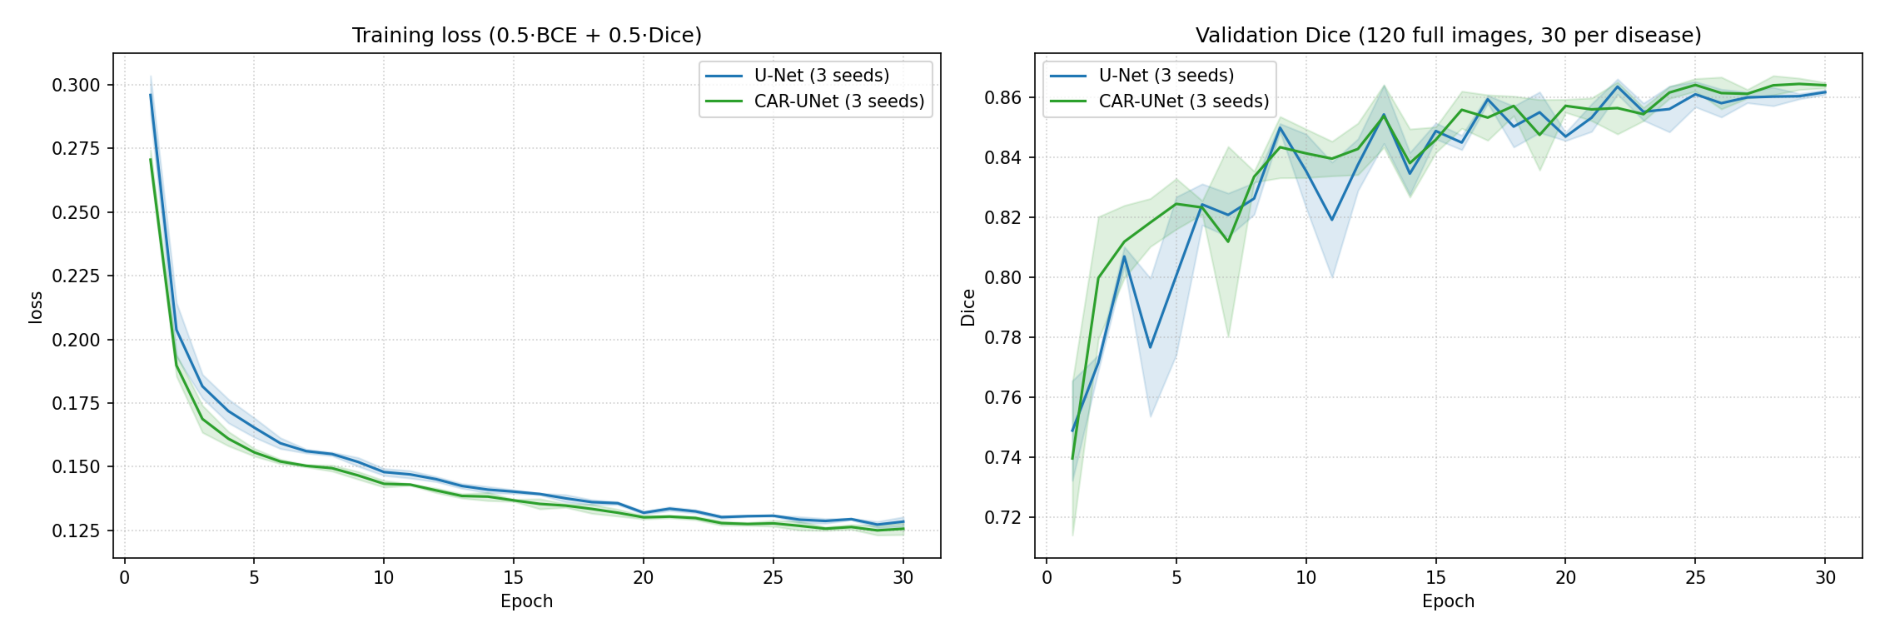

In [7]:
# Load the seed-0 models (used for the live demo below)
SEED = 0
unet_fives = UNet(in_channels=1, out_channels=1, base_filters=64).to(device)
unet_ckpt = torch.load(f'models/unet_seed{SEED}.pt', map_location=device, weights_only=False)
unet_fives.load_state_dict(unet_ckpt['model_state_dict'])
unet_fives.eval()

car_unet_fives = CARUNet(in_channels=1, out_channels=1, base_filters=64).to(device)
car_ckpt = torch.load(f'models/car_unet_seed{SEED}.pt', map_location=device, weights_only=False)
car_unet_fives.load_state_dict(car_ckpt['model_state_dict'])
car_unet_fives.eval()

print(f'U-Net    (seed {SEED}): best epoch {unet_ckpt["epoch"]:2d}, val Dice {unet_ckpt["best_val_dice"]:.4f}')
print(f'CAR-UNet (seed {SEED}): best epoch {car_ckpt["epoch"]:2d}, val Dice {car_ckpt["best_val_dice"]:.4f}')

# Training curves, mean ± std over all seeds (generated by scripts/make_figures.py)
plt.figure(figsize=(16, 5.5))
plt.imshow(Image.open('outputs/training_curves.png'))
plt.axis('off')
plt.show()


---
## 8. Benchmark Results on All 200 FIVES Test Images

Metrics are computed per image inside the field of view (threshold 0.5) and averaged over the 200 test images; values are mean ± std over 3 training seeds. The table is produced by `scripts/summarize_results.py` from `results/runs/`.

*The Review 1 DRIVE result (Dice 0.759 on 4 DRIVE validation images) is not in this table because it was measured on a different dataset and is not directly comparable.*


In [8]:
df_comp = pd.read_csv('results/comparison_table.csv')
metrics = ['Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F1_Dice', 'IoU', 'AUC_ROC', 'AUC_PR']
table = pd.DataFrame({'Model': df_comp['Model'], 'Seeds': df_comp['Seeds'], 'Params (M)': (df_comp['Parameters'] / 1e6).round(1)})
for m in metrics:
    table[m] = [f'{mu:.4f} ± {sd:.4f}' for mu, sd in zip(df_comp[m], df_comp[m + '_std'])]
print('OVERALL (200 test images)')
print(table.to_string(index=False))

df_dis = pd.read_csv('results/per_disease_table.csv')
print('\nPER DISEASE (50 test images each)')
print(df_dis.pivot(index='Disease', columns='Model', values='F1_Dice').round(4).add_prefix('Dice ').to_string())

# Paired significance test on per-image Dice (from results/RESULTS_TABLE.md)
md = open('results/RESULTS_TABLE.md', encoding='utf-8').read()
print('\n' + md[md.find('Paired Wilcoxon'):md.find('## Individual runs')].strip())


OVERALL (200 test images)
                       Model  Seeds  Params (M)        Accuracy     Sensitivity     Specificity       Precision         F1_Dice             IoU         AUC_ROC          AUC_PR
                       U-Net      3        31.0 0.9723 ± 0.0005 0.8247 ± 0.0078 0.9852 ± 0.0008 0.8573 ± 0.0047 0.8344 ± 0.0034 0.7246 ± 0.0050 0.9847 ± 0.0008 0.9174 ± 0.0024
                    CAR-UNet      3        32.4 0.9728 ± 0.0007 0.8310 ± 0.0126 0.9855 ± 0.0018 0.8557 ± 0.0151 0.8382 ± 0.0031 0.7295 ± 0.0043 0.9860 ± 0.0014 0.9202 ± 0.0044
               CAR-UNet + DA      3        32.4 0.9735 ± 0.0005 0.8308 ± 0.0005 0.9862 ± 0.0005 0.8620 ± 0.0049 0.8408 ± 0.0021 0.7339 ± 0.0034 0.9860 ± 0.0001 0.9218 ± 0.0012
      CAR-UNet + DA + clDice      3        32.4 0.9723 ± 0.0009 0.8432 ± 0.0071 0.9835 ± 0.0004 0.8430 ± 0.0048 0.8382 ± 0.0050 0.7293 ± 0.0077 0.9866 ± 0.0007 0.9207 ± 0.0032
CAR-UNet + DA + clDice @1024      3        32.4 0.9739 ± 0.0007 0.8326 ± 0.0069 0.9863 ± 0.001

---
## 9. Visual Comparison — One Typical Test Image per Disease

For each disease group the image shown is the one with the **median** CAR-UNet Dice, so these are typical cases rather than hand-picked best ones. Error maps: **green** = correct vessel, **red** = false vessel, **blue** = missed vessel.


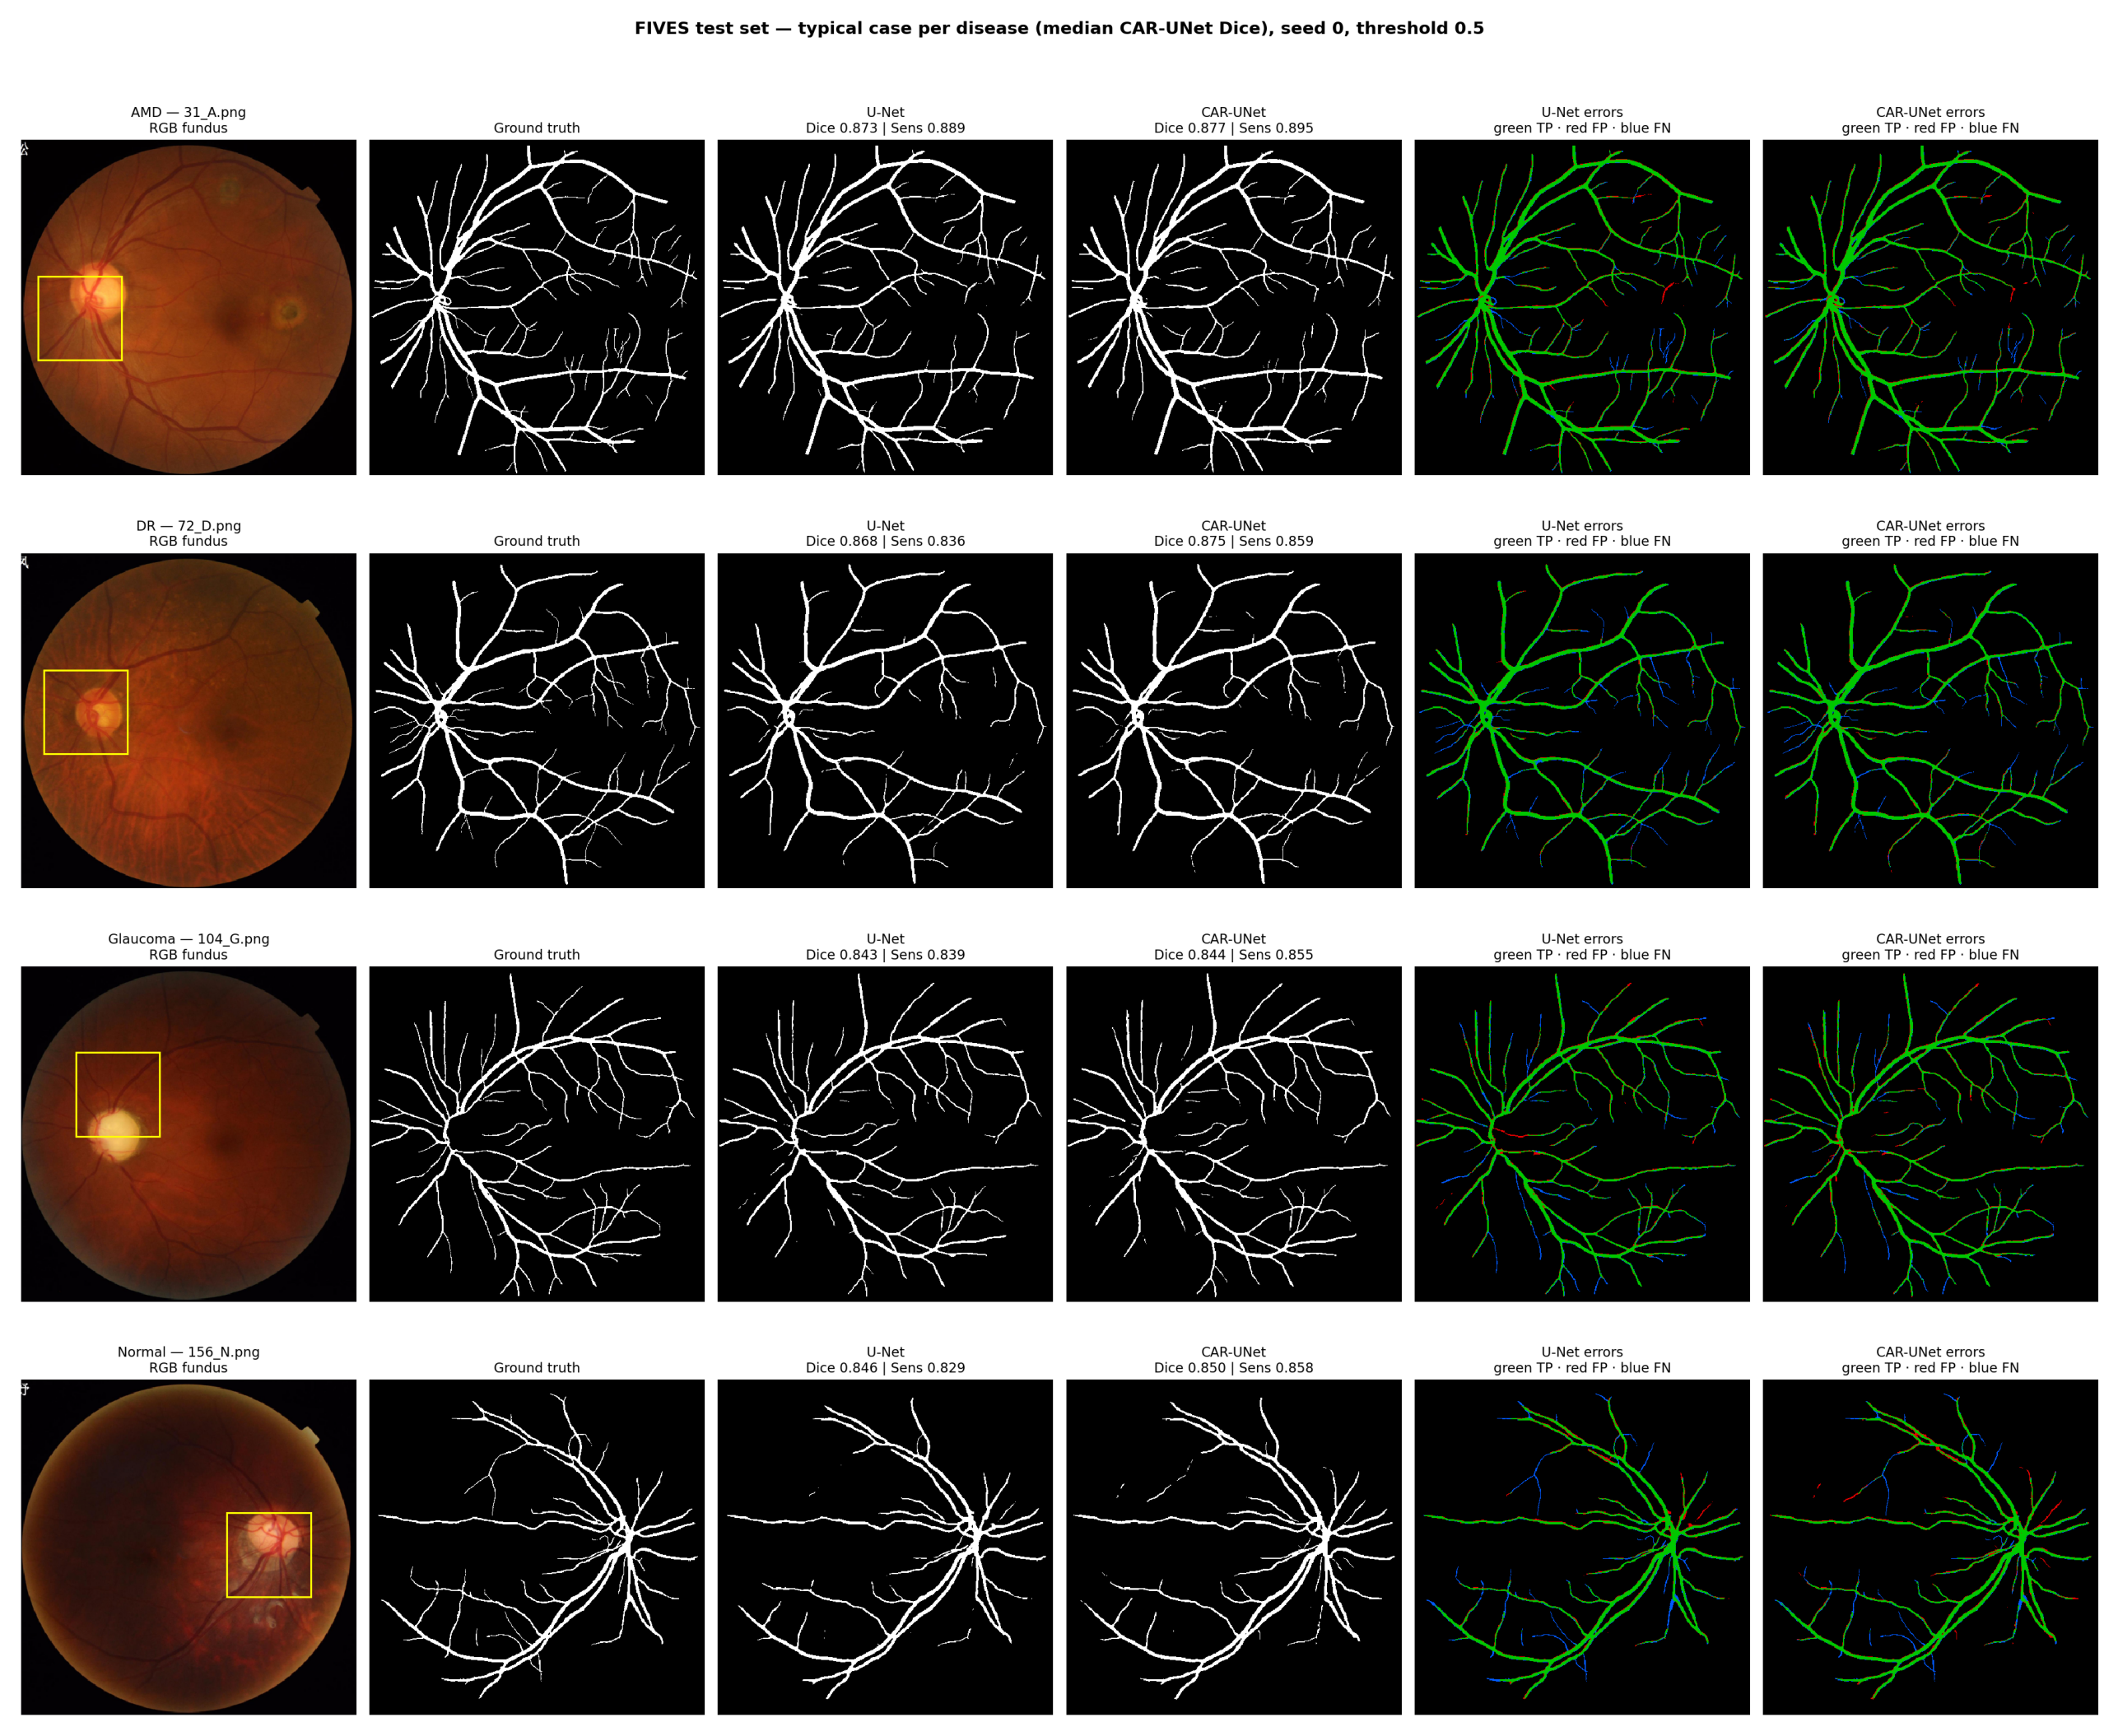

In [9]:
plt.figure(figsize=(24, 18))
plt.imshow(Image.open('outputs/final_comparison_figure.png'))
plt.axis('off')
plt.show()


---
## 10. Live Test Sample Inference with Clinical Error Maps
Runs live full-resolution inference on a held-out test sample and plots the clinical error map:
- **Green**: True Positive (Correctly segmented vessel)
- **Red**: False Positive (Over-segmentation)
- **Blue**: False Negative (Missed thin capillary)

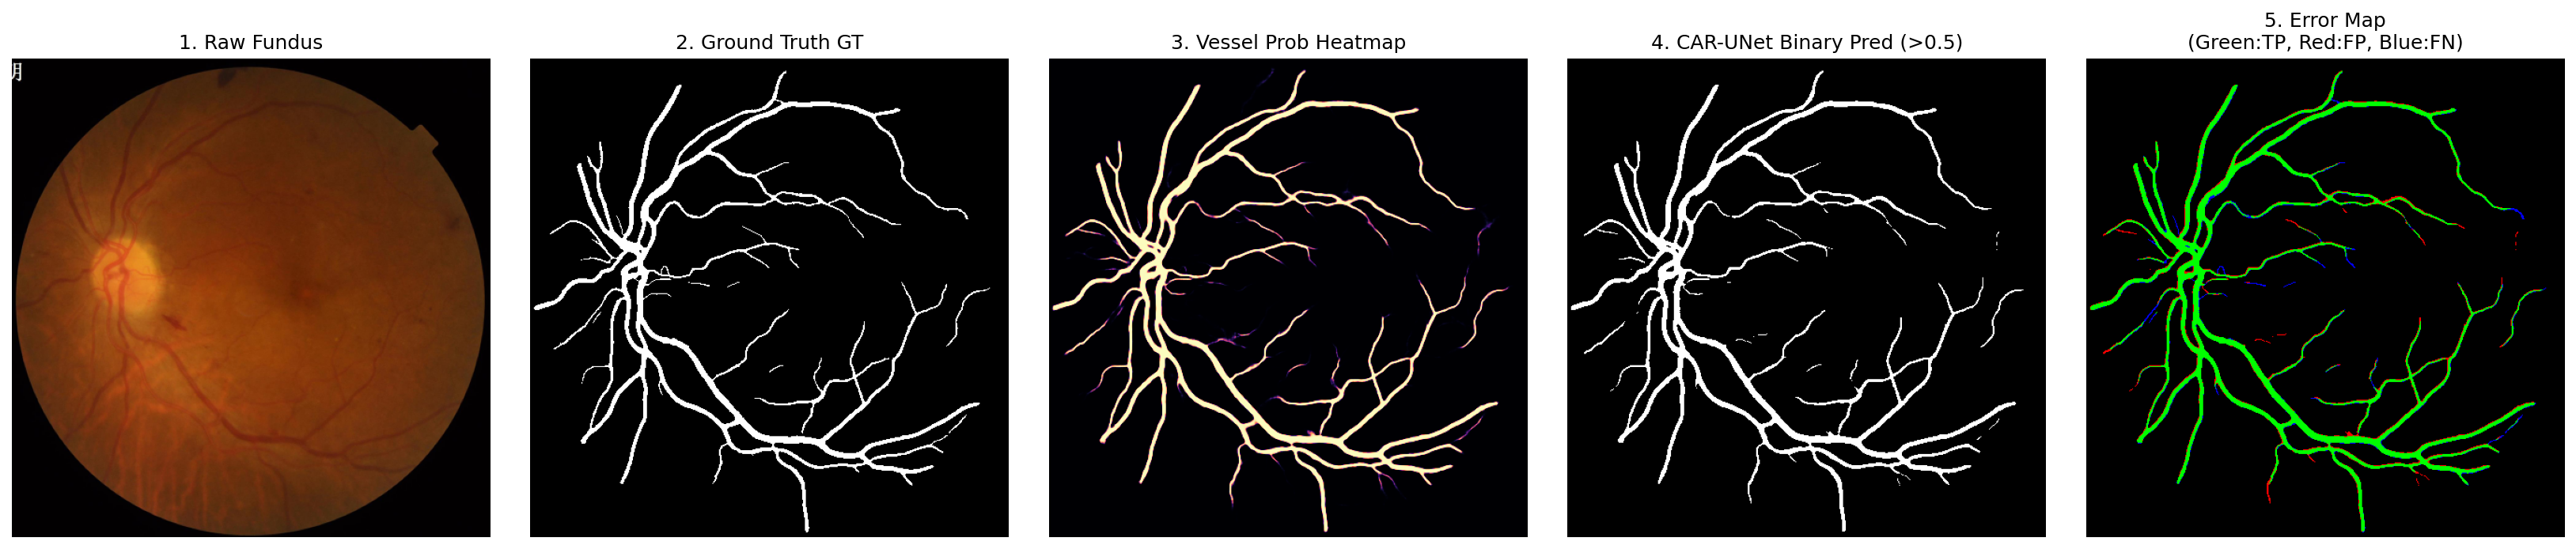

In [10]:
test_pairs = load_fives_image_pairs('data/FIVES_resized', mode='test')
test_img_path, test_mask_path = test_pairs[0]

raw_bgr = cv2.imread(test_img_path)
raw_rgb = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)
prep_img = preprocess_image(raw_rgb)
fov_mask = generate_fov_mask(raw_rgb)
gt_mask = (cv2.imread(test_mask_path, cv2.IMREAD_GRAYSCALE) > 128).astype(np.float32)

# Run CAR-UNet Prediction
pred_prob = predict_full_image(car_unet_fives, prep_img, fov_mask, in_patch_size=284, device=device)
pred_bin = (pred_prob >= 0.5).astype(np.float32) * fov_mask

# Build Clinical Error Map
error_map = np.zeros((*gt_mask.shape, 3), dtype=np.uint8)
tp_mask = (gt_mask > 0.5) & (pred_bin > 0.5) & (fov_mask > 0.5)
fp_mask = (gt_mask <= 0.5) & (pred_bin > 0.5) & (fov_mask > 0.5)
fn_mask = (gt_mask > 0.5) & (pred_bin <= 0.5) & (fov_mask > 0.5)

error_map[tp_mask] = [0, 255, 0]   # Green = TP
error_map[fp_mask] = [255, 0, 0]   # Red = FP
error_map[fn_mask] = [0, 0, 255]   # Blue = FN

fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
axes[0].imshow(raw_rgb); axes[0].set_title('1. Raw Fundus'); axes[0].axis('off')
axes[1].imshow(gt_mask, cmap='gray'); axes[1].set_title('2. Ground Truth GT'); axes[1].axis('off')
axes[2].imshow(pred_prob, cmap='magma'); axes[2].set_title('3. Vessel Prob Heatmap'); axes[2].axis('off')
axes[3].imshow(pred_bin, cmap='gray'); axes[3].set_title('4. CAR-UNet Binary Pred (>0.5)'); axes[3].axis('off')
axes[4].imshow(error_map); axes[4].set_title('5. Error Map\n(Green:TP, Red:FP, Blue:FN)'); axes[4].axis('off')
plt.tight_layout()
plt.show()


---
## 11. Findings & Conclusions

### Quantitative results (200 test images, mean ± std over 3 seeds)
1. **Dice / F1**: CAR-UNet **0.8382 ± 0.0031** vs U-Net 0.8344 ± 0.0034 (+0.0038). CAR-UNet is better on **154 of 200** test images (paired Wilcoxon p = 2.2×10⁻¹⁴).
2. **Sensitivity (vessel recall)**: 0.8310 vs 0.8247 (+0.0063) — CAR-UNet finds slightly more vessel pixels, at almost the same precision (0.8557 vs 0.8573).
3. **AUC-ROC**: 0.9860 vs 0.9847; **Accuracy**: 0.9728 vs 0.9723.
4. **Per disease**: gains are largest on **Glaucoma (+0.0071)** and **Normal (+0.0055)**; Glaucoma is the hardest group for both models (Dice ≈ 0.79).

### Honest assessment
- The improvement is **real but small**: it is about the size of the variation between training runs (CAR-UNet was better in 2 of 3 seeds), and CAR-UNet needs ~27% more training time.
- Most remaining errors are **missed thin capillaries** (blue in the error maps), partly because images were downsampled from 2048×2048 to 512×512.
- Two very low-quality Glaucoma test images (122_G, 123_G) fail for both models (Dice < 0.1); they are kept in the test set.

### Next: improvements
These weaknesses are addressed by the four improvements in Section 12 (details: `IMPROVEMENTS.md`).


---
## 12. Improvements over the paper

Each improvement targets one weakness of the CAR-UNet paper (full description: `IMPROVEMENTS.md`):

| # | Paper weakness | Improvement |
|---|---|---|
| 1 | Channel attention only — no information on *where* vessels are | **Dual attention**: channel attention from average + max pooling (paper Eq. 3) + spatial attention |
| 2 | Pixel-wise loss — broken thin vessels cost almost nothing | **clDice loss** (vessel-skeleton overlap) added to BCE + Dice |
| 3 | Low working resolution — thin capillaries lost at 512×512 | **Training and prediction at 1024×1024** (scored on the same 512 ground truth) |
| 4 | Fixed 0.5 threshold | **Threshold tuned on the validation set** (flip TTA was also tested and did not help) |

The table below is the ablation (each step adds one improvement), read from `results/ablation_table.csv` (built by `scripts/summarize_post.py`).

In [11]:
abl = pd.read_csv('results/ablation_table.csv')
print(abl.to_string(index=False))


                                                                       Step  Seeds         F1_Dice     Sensitivity       Precision         AUC_ROC          clDice   hires_F1_Dice
                                                                      U-Net      3 0.8344 ± 0.0034 0.8247 ± 0.0078 0.8573 ± 0.0047 0.9847 ± 0.0008 0.8593 ± 0.0026             NaN
                                                                   CAR-UNet      3 0.8382 ± 0.0031 0.8310 ± 0.0126 0.8557 ± 0.0151 0.9860 ± 0.0014 0.8626 ± 0.0057 0.8572 ± 0.0125
                    CAR-UNet + Improvement 4 (setting chosen on validation)      3 0.8387 ± 0.0035 0.8343 ± 0.0074 0.8530 ± 0.0033 0.9860 ± 0.0014 0.8632 ± 0.0065             NaN
                                                              CAR-UNet + DA      3 0.8408 ± 0.0021 0.8308 ± 0.0005 0.8620 ± 0.0049 0.9860 ± 0.0001 0.8631 ± 0.0020 0.8613 ± 0.0015
               CAR-UNet + DA + Improvement 4 (setting chosen on validation)      3 0.8410 ± 0.0021 0.8349

### Final model vs CAR-UNet — typical test image per disease, and zoom on thin vessels
Columns: RGB | ground truth | CAR-UNet | final model | error maps (green = correct, red = false vessel, blue = missed vessel).

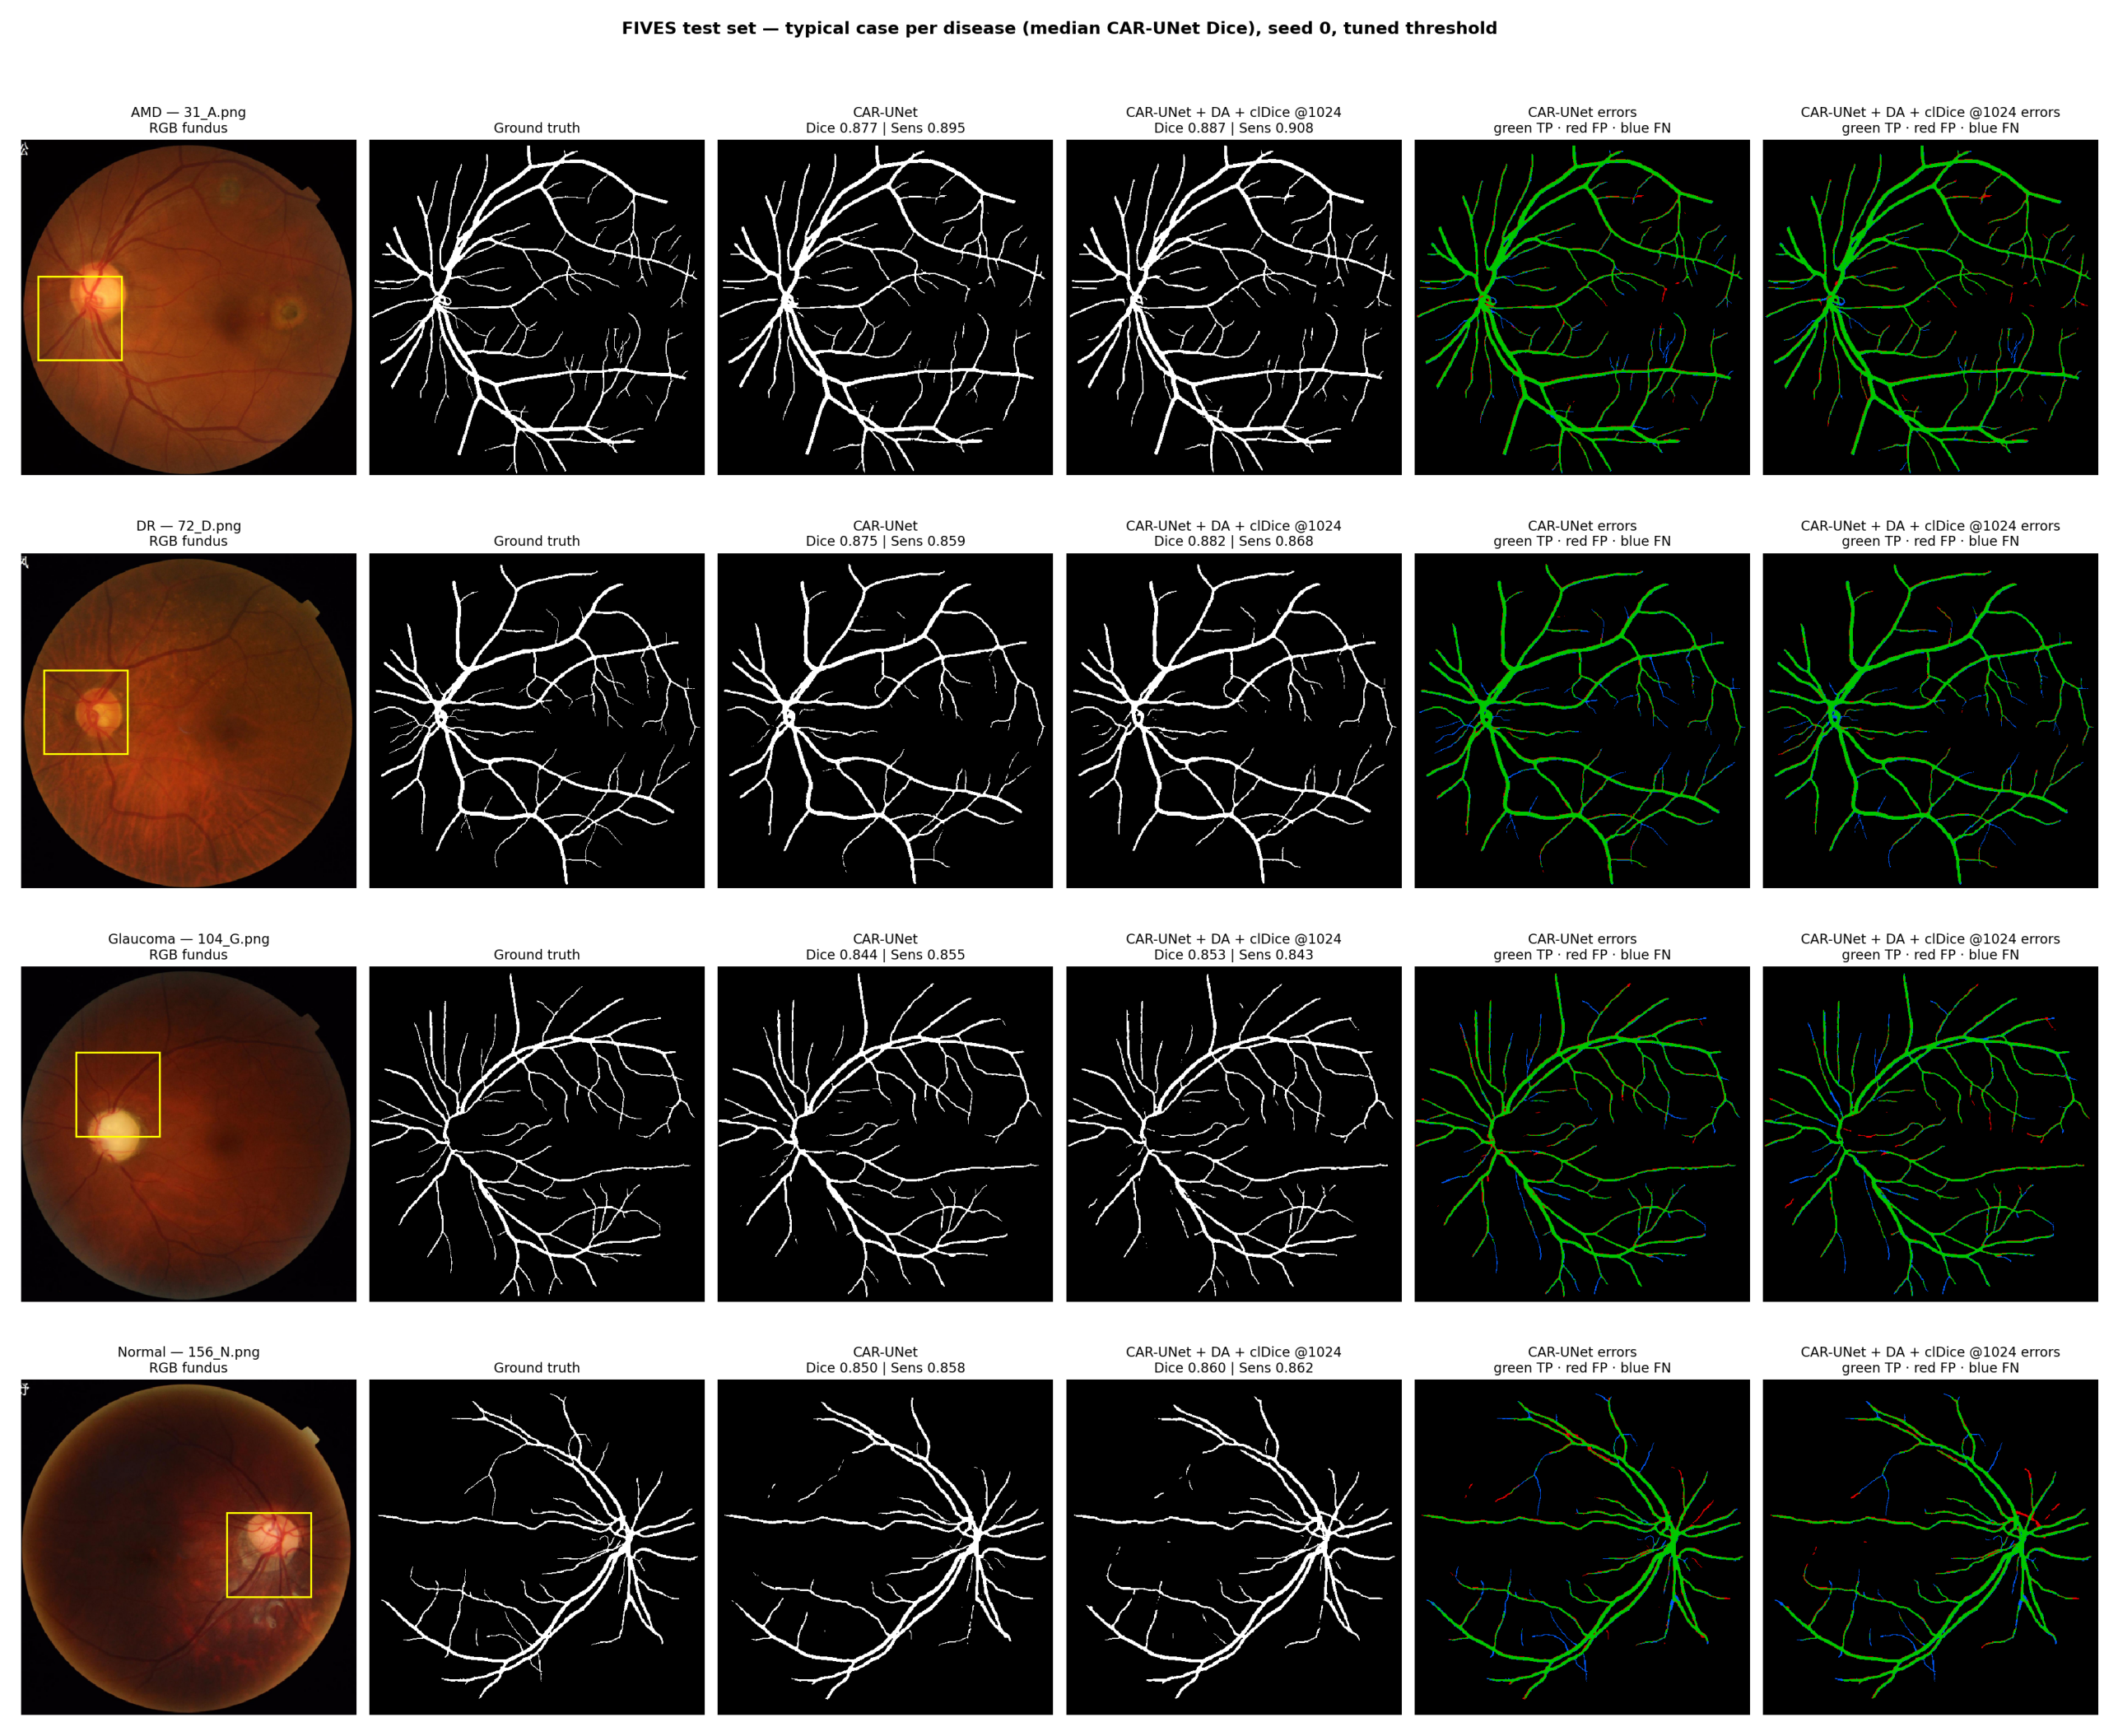

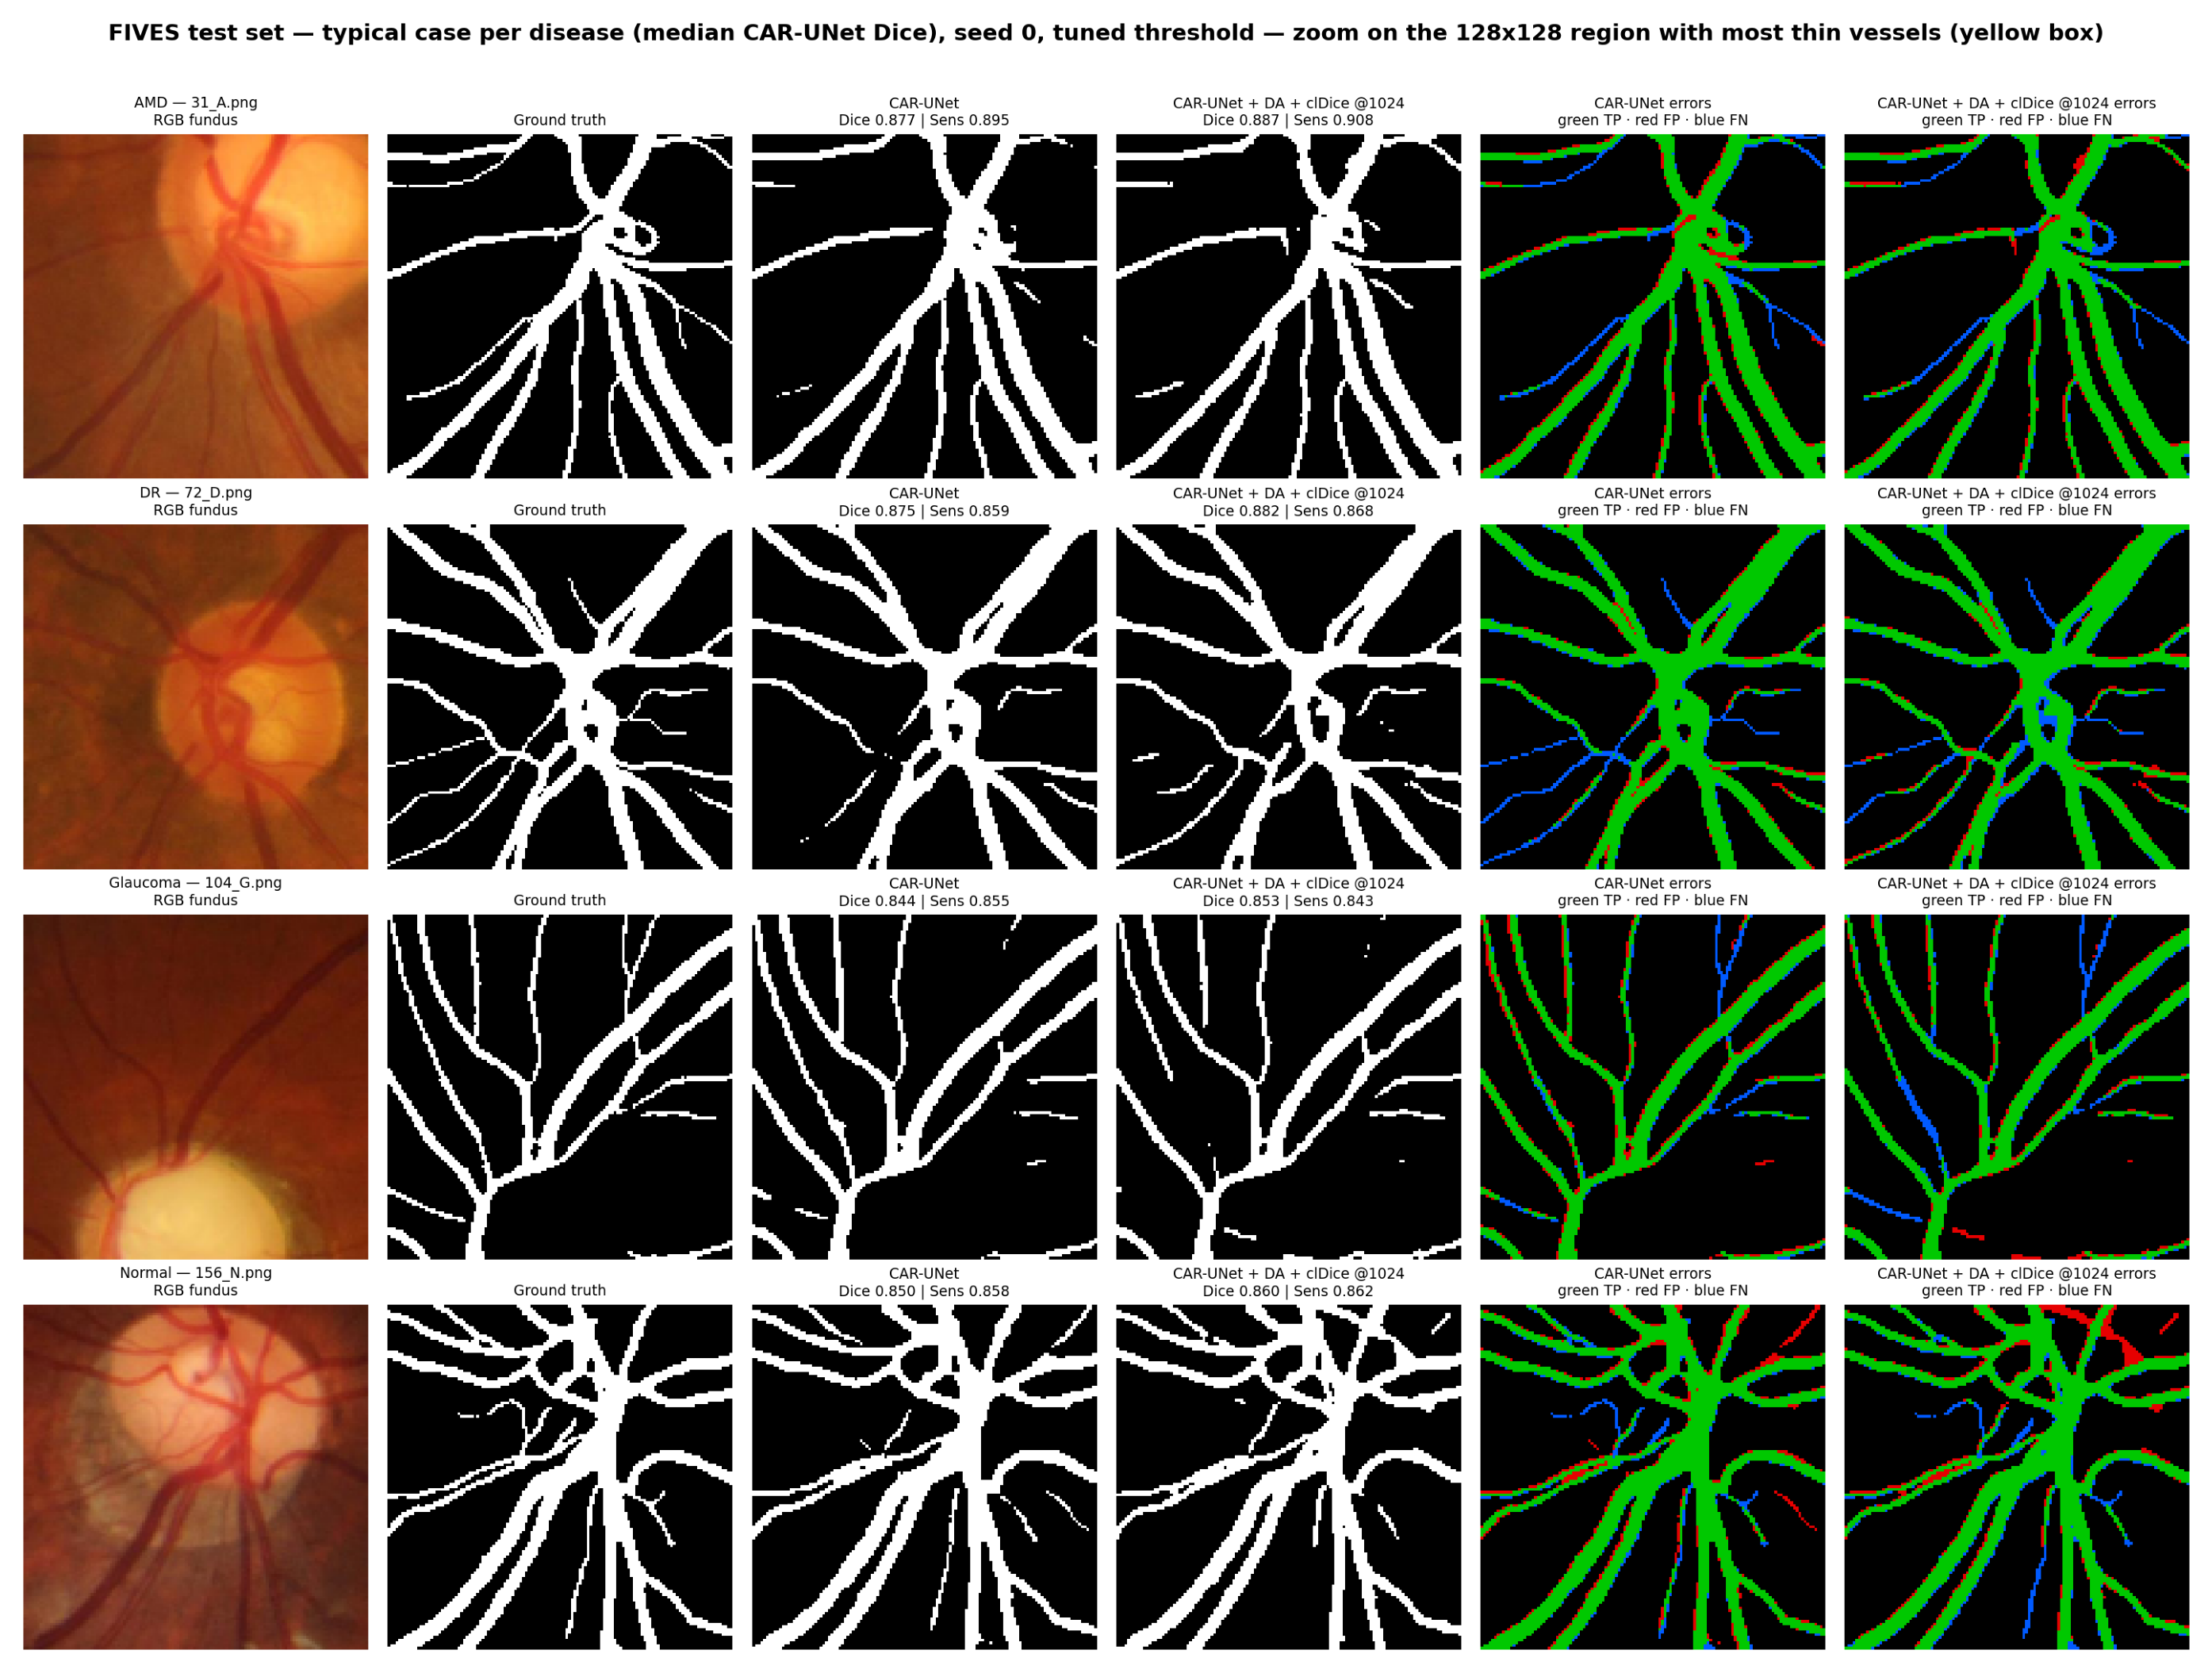

In [12]:
for fig_path in ['outputs/final_model_comparison.png', 'outputs/thin_vessel_zoom.png']:
    plt.figure(figsize=(24, 18))
    plt.imshow(Image.open(fig_path))
    plt.axis('off')
    plt.show()
